# **DASK Scaling**

**Version:** 1.0 | **Last updated:** 2026-08-11

**Author:** Asif Ashraf | **Author institution:** EarthScope Consortium

**Maintainer:** EarthScope OnRamp Team | **Maintainer's contact:** help@earthscope.org

**License:** CC-BY-4.0

---

### **Introduction**

Preparing data from many seismic stations can take time. For each station, we need to download the waveform, clean and resample it, and identify the P-wave arrival. Because each station can be processed independently, we can prepare several waveforms at the same time.

In this notebook, `dask` distributes these tasks across multiple threads. We then combine the prepared waveforms into a training dataset and use PyTorch to train a small convolutional neural network.

The goal is to demonstrate a complete workflow: using Dask to prepare seismic data in parallel and then using that data to train a neural network.

### **Learning objectives**

By the end of this notebook, you will be able to:

- submit independent tasks with Dask `Futures`;
- collect results as tasks finish;
- visualize concurrent execution across threads; and
- pass prepared data from Dask to a neural-network workflow.

### **Table of Contents**

1. [Set up Dask](#1-set-up-dask)
2. [Build the request queue](#2-build-the-request-queue)
3. [Prepare one waveform](#3-prepare-one-waveform)
4. [Submit a Future](#4-submit-a-future)
5. [Stream data in parallel](#5-stream-data-in-parallel)
6. [Build the training dataset](#6-build-the-training-dataset)
7. [Train the CNN](#7-train-the-cnn)
8. [Evaluate predictions](#8-evaluate-predictions)
9. [Conclusion](#9-conclusion)

---

### **1. Set up Dask**

A Dask `Client` sends tasks to a scheduler. Here, one local Dask process runs four execution threads. Threads share memory and are well suited to this workflow because waveform downloads are I/O-bound and NumPy, ObsPy, and PyTorch perform substantial work outside the Python Global Interpreter Lock.

In [1]:
from dask.distributed import Client, LocalCluster, as_completed, get_task_stream

N_THREADS = 4

cluster = LocalCluster(n_workers=1, threads_per_worker=N_THREADS,
                       processes=False, memory_limit="auto")

client = Client(cluster)

print(f"Dask is ready with {N_THREADS} execution threads.")
client

Dask is ready with 4 execution threads.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/8787/status,
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/8787/status,Workers: 1
Total threads: 4,Total memory: 3.63 GiB
Status: running,Using processes: False
Comm: inproc://192.168.6.159/396/1,Workers: 0
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: inproc://192.168.6.159/396/4,Total threads: 4
Dashboard: /user/google-oauth2%7C112154804904828697217/proxy/43991/status,Memory: 3.63 GiB
Nanny: None,


On GeoLab, a Dask Gateway cluster can replace `LocalCluster`. Only the cluster-creation cell changes:

```python
from dask_gateway import Gateway

gateway = Gateway()
cluster = gateway.new_cluster(gateway.cluster_options())
cluster.adapt(minimum=2, maximum=10)
client = cluster.get_client()
```

Adaptive scaling adds resources when tasks accumulate and releases them when demand falls.

##### **Imports**

This notebook uses `obspy`, `dask.distributed`, `matplotlib`, `numpy`, `seisbench`, and `torch`. The first four appeared in the earlier notebooks. **PyTorch and Seisbench are new here**, so the cell below checks if they exist in the current session, and if not, we install them via `pip`

In [2]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except:
    print("PyTorch not found. Installing it ...")
    !pip install torch
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

try:
    import seisbench.models as sbm
except:
    print("Seisbench not found. Installing it ...")
    !pip install seisbench
    import seisbench.models as sbm

The remaining libraries support waveform access, preprocessing, labeling, visualization, and neural-network training.

In [3]:
from functools import lru_cache
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import seisbench.models as sbm
import torch
import torch.nn as nn
from obspy import UTCDateTime
from obspy.clients.fdsn import Client as FDSNClient
from torch.utils.data import DataLoader, TensorDataset

rng = np.random.default_rng(42)
torch.manual_seed(42)
torch.set_num_threads(1)

### **2. Build the request queue**

The example uses the M4.6 earthquake near Monroe, Washington, on 12 July 2019. We request three-component waveforms from nearby stations of `UW` network. Each request is a small dictionary and can be processed independently.

In [4]:
PROVIDER = "EARTHSCOPE"
EVENT = {"time": "2019-07-12T09:51:38", "latitude": 47.873, "longitude": -122.016}
NETWORK, CHANNEL = "UW", "HH?"
SEARCH_RADIUS_KM = 150
PRE_TIME, POST_TIME = 5, 40
TARGET_SAMPLING_RATE = 50
P_THRESHOLD = 0.2
MAX_STATIONS = 40

event_time = UTCDateTime(EVENT["time"])
inventory = FDSNClient(PROVIDER).get_stations(network=NETWORK, station="*", 
                                              location="*", channel=CHANNEL, 
                                              latitude=EVENT["latitude"], longitude=EVENT["longitude"],
                                              maxradius=SEARCH_RADIUS_KM / 111.2,
                                              starttime=event_time, endtime=event_time + 1, level="response")

request_by_station = {}
for network in inventory:
    for station in network:
        for channel in station:
            request_by_station.setdefault(
                station.code,
                {
                    "provider": PROVIDER,
                    "network": network.code,
                    "station": station.code,
                    "location": channel.location_code or "",
                    "channel": CHANNEL,
                },
            )

requests = [request_by_station[key] for key in sorted(request_by_station)[:MAX_STATIONS]]
print(f"Prepared {len(requests)} independent station requests.")

Prepared 21 independent station requests.


### **3. Prepare one waveform**

Each task performs the complete preparation workflow for one station:

1. download a three-component waveform;
2. use PhaseNet to identify the P arrival;
3. select, filter, resample, and standardize the vertical component; and
4. return compact NumPy arrays for training.

PhaseNet labels are convenient and consistent, but they are model-generated labels rather than reviewed analyst picks.

In [5]:
@lru_cache(maxsize=1)
def get_picker():
    return sbm.PhaseNet.from_pretrained("original")
get_picker()  # Download once and reuse across tasks.
print(f"Phasenet is ready!")

Phasenet is ready!


In [6]:
def fetch_and_prepare(request):
    # Download, label, and standardize one station waveform.
    try:
        start = event_time - PRE_TIME
        end = event_time + POST_TIME
        n_samples = int((PRE_TIME + POST_TIME) * TARGET_SAMPLING_RATE)

        stream = FDSNClient(request["provider"]).get_waveforms(request["network"], request["station"],
                                                               request["location"], request["channel"],
                                                               start, end)
        stream.merge(method=1, fill_value="interpolate")

        output = get_picker().classify(stream, P_threshold=P_THRESHOLD)
        picks = getattr(output, "picks", output)
        p_picks = [pick for pick in picks if pick.phase == "P"]
        if not p_picks:
            return None

        best_pick = max(p_picks, key=lambda pick: pick.peak_value)
        pick_sample = round((best_pick.peak_time - start) * TARGET_SAMPLING_RATE)
        if not 0 <= pick_sample < n_samples:
            return None

        vertical = stream.select(component="Z")
        if not vertical:
            return None

        trace = max(vertical, key=lambda item: item.stats.npts).copy()
        trace.detrend("linear").detrend("demean").taper(max_percentage=0.05)
        if trace.stats.sampling_rate > TARGET_SAMPLING_RATE:
            trace.filter("lowpass", freq=0.4 * TARGET_SAMPLING_RATE, zerophase=True)

        trace.trim(start - 1, end + 1, pad=True, fill_value=0)
        trace.interpolate(TARGET_SAMPLING_RATE, starttime=start,
                          npts=n_samples, method="linear")

        waveform = np.asarray(trace.data, dtype=np.float32)
        scale = np.std(waveform)
        if scale == 0:
            return None
        waveform = (waveform - np.median(waveform)) / scale

        label = np.zeros(n_samples, dtype=np.int64)
        half_width = round(0.25 * TARGET_SAMPLING_RATE)
        label[max(0, pick_sample - half_width):pick_sample + half_width + 1] = 1

        return {"station": request["station"], "waveform": waveform, "label": label}
    except Exception:
        return None

### **4. Submit a Future**

`client.submit()` schedules one task immediately and returns a `Future`, which represents a result that may still be pending or running. Calling `.result()` waits only for that task.

In [7]:
first_future = client.submit(fetch_and_prepare, requests[0], pure=False)
print(first_future)

first_result = first_future.result()
print(f"Completed station: {first_result['station'] if first_result else 'skipped'}")

<Future: pending, key: fetch_and_prepare-6b9fb747-734e-4572-b7dc-975306f95e7c>
Completed station: BERY


`pure=False` tells Dask to execute the call each time it is submitted. This is appropriate for remote data access because the result can change even when the request is identical.

### **5. Stream data in parallel**

`client.map()` submits the remaining station requests. `as_completed()` yields each result as soon as it finishes, while `get_task_stream()` records the execution timeline. The four threads can overlap downloads and preprocessing instead of handling stations sequentially.

In [8]:
records = [first_result] if first_result else []

with get_task_stream(client) as task_stream:
    start = perf_counter()
    futures = client.map(fetch_and_prepare, requests[1:], pure=False)
    for future in as_completed(futures):
        result = future.result()
        if result is not None:
            records.append(result)
    batch_runtime = perf_counter() - start

print(f"Prepared {len(records)} waveforms in {batch_runtime:.2f} s with {N_THREADS} threads.")

Prepared 20 waveforms in 1.77 s with 4 threads.


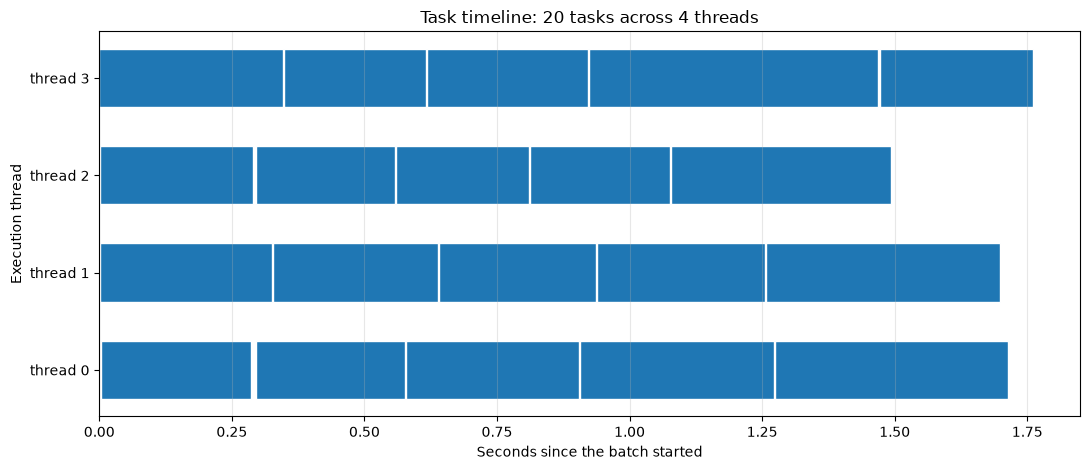

Average threads busy: 3.76 of 4


In [9]:
computations = [
    (item["thread"], step["start"], step["stop"])
    for item in task_stream.data
    for step in item.get("startstops", [])
    if step.get("action") == "compute"
]

t_zero = min(start for _, start, _ in computations)
thread_ids = sorted({thread for thread, _, _ in computations})
thread_row = {thread: row for row, thread in enumerate(thread_ids)}

plt.figure(figsize=(11, 0.7 * len(thread_ids) + 2))
for thread, start, stop in computations:
    plt.barh(
        thread_row[thread],
        stop - start,
        left=start - t_zero,
        height=0.6,
        color="tab:blue",
        edgecolor="white",
    )

plt.yticks(range(len(thread_ids)), [f"thread {i}" for i in range(len(thread_ids))])
plt.xlabel("Seconds since the batch started")
plt.ylabel("Execution thread")
plt.title(f"Task timeline: {len(computations)} tasks across {len(thread_ids)} threads")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

busy_time = sum(stop - start for _, start, stop in computations)
wall_time = max(stop for _, _, stop in computations) - t_zero
print(f"Average threads busy: {busy_time / wall_time:.2f} of {len(thread_ids)}")

Overlapping bars show concurrent execution. The average number of busy threads summarizes how fully the available thread pool was used during the batch.

### **6. Build the training dataset**

Dask handles independent data access and preprocessing; PyTorch handles minibatches, gradients, and model optimization. The prepared arrays are small enough to assemble in notebook memory. For larger datasets, each task should write a chunked result, such as Zarr, that the training pipeline can stream from storage.

In [10]:
records = sorted(records, key=lambda item: item["station"])
X = np.stack([item["waveform"] for item in records])[:, None, :]
y = np.stack([item["label"] for item in records])

order = rng.permutation(len(records))
split = int(0.8 * len(records))
train_indices, validation_indices = order[:split], order[split:]

X_train, y_train = X[train_indices], y[train_indices]
X_validation, y_validation = X[validation_indices], y[validation_indices]
validation_stations = [records[index]["station"] for index in validation_indices]

print(f"Training traces: {len(X_train)}")
print(f"Validation traces: {len(X_validation)}")

Training traces: 16
Validation traces: 4


### **7. Train the CNN**

The model is a compact 1-D CNN that predicts either background or P arrival at every time sample. Padding preserves the time axis so predictions align directly with the waveform. Class weighting gives additional importance to the relatively rare P-arrival samples.

In [11]:
class PlainCNN(nn.Module):
    def __init__(self, kernel_size=15, width=32):
        super().__init__()
        padding = kernel_size // 2
        self.layers = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size, padding=padding),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(16, width, kernel_size, padding=padding),
            nn.BatchNorm1d(width),
            nn.ReLU(),
            nn.Conv1d(width, width, kernel_size, padding=padding),
            nn.BatchNorm1d(width),
            nn.ReLU(),
            nn.Conv1d(width, 2, 1),
        )

    def forward(self, waveform):
        return self.layers(waveform)


model = PlainCNN()
print(f"Trainable parameters: {sum(parameter.numel() for parameter in model.parameters()):,}")

Trainable parameters: 23,586


In [12]:
BATCH_SIZE, EPOCHS, LEARNING_RATE = 4, 30, 1e-3

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_validation), torch.from_numpy(y_validation)),
    batch_size=BATCH_SIZE,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
positive_weight = min(30.0, (y_train.size - y_train.sum()) / y_train.sum())
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, positive_weight], device=device))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses, validation_losses = [], []
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for waveforms, labels in train_loader:
        waveforms, labels = waveforms.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(waveforms), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(waveforms)

    model.eval()
    validation_loss = 0.0
    with torch.no_grad():
        for waveforms, labels in validation_loader:
            waveforms, labels = waveforms.to(device), labels.to(device)
            validation_loss += criterion(model(waveforms), labels).item() * len(waveforms)

    train_losses.append(train_loss / len(X_train))
    validation_losses.append(validation_loss / len(X_validation))

print(f"Training completed on {device}.")

Training completed on cpu.


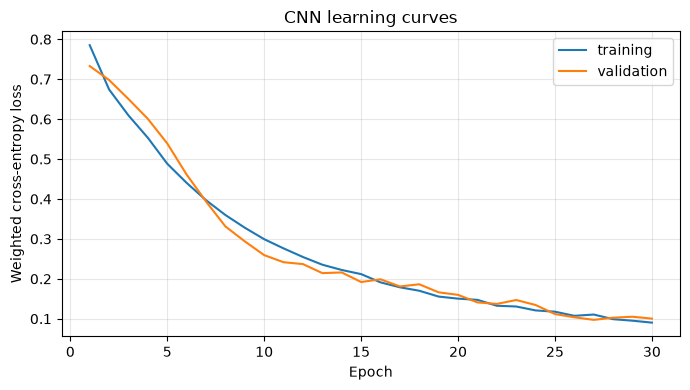

In [13]:
epochs = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs, train_losses, label="training")
plt.plot(epochs, validation_losses, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Weighted cross-entropy loss")
plt.title("CNN learning curves")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### **8. Evaluate predictions**

For each validation waveform, the predicted P arrival is the sample with the highest P probability. Absolute timing error provides an intuitive summary of the model's predictions on this small demonstration dataset.

In [14]:
def label_centres(labels):
    return np.array([np.flatnonzero(label).mean() for label in labels])


model.eval()
with torch.no_grad():
    probabilities = torch.softmax(model(torch.from_numpy(X_validation).to(device)), dim=1)[:, 1]

p_probability = probabilities.cpu().numpy()
predicted_samples = p_probability.argmax(axis=1)
true_samples = label_centres(y_validation)
errors = np.abs(predicted_samples - true_samples) / TARGET_SAMPLING_RATE

print(f"Median absolute error: {np.median(errors):.2f} s")
print(f"Picks within 0.5 s: {(errors <= 0.5).sum()} of {len(errors)}")

Median absolute error: 0.05 s
Picks within 0.5 s: 4 of 4


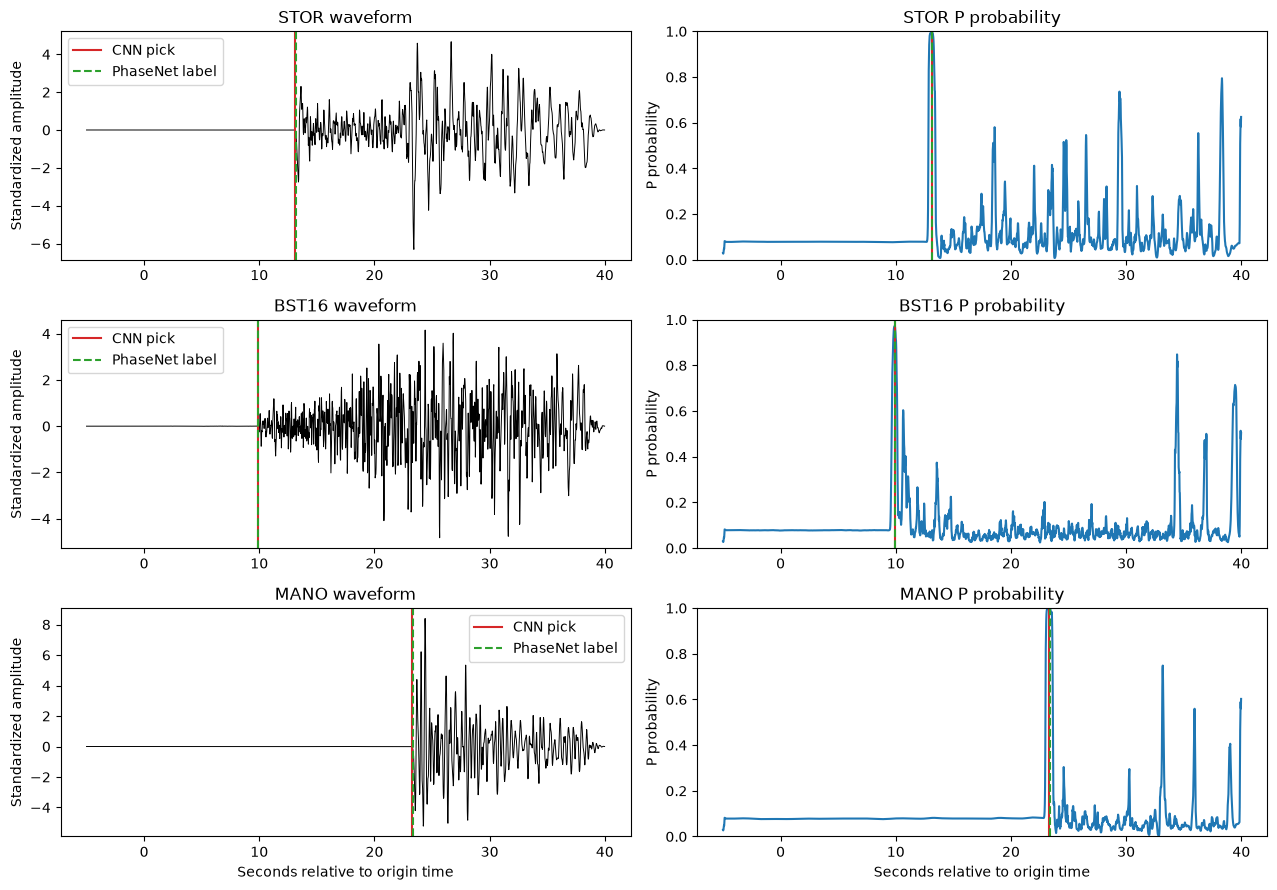

In [15]:
example_count = min(3, len(X_validation))
time_axis = np.arange(X_validation.shape[-1]) / TARGET_SAMPLING_RATE - PRE_TIME
fig, axes = plt.subplots(example_count, 2, figsize=(13, 3 * example_count), squeeze=False)

for index in range(example_count):
    true_time = time_axis[round(true_samples[index])]
    predicted_time = time_axis[predicted_samples[index]]

    axes[index, 0].plot(time_axis, X_validation[index, 0], color="black", lw=0.7)
    axes[index, 0].axvline(predicted_time, color="tab:red", label="CNN pick")
    axes[index, 0].axvline(true_time, color="tab:green", ls="--", label="PhaseNet label")
    axes[index, 0].set_title(f"{validation_stations[index]} waveform")
    axes[index, 0].set_ylabel("Standardized amplitude")
    axes[index, 0].legend()

    axes[index, 1].plot(time_axis, p_probability[index], color="tab:blue")
    axes[index, 1].axvline(predicted_time, color="tab:red")
    axes[index, 1].axvline(true_time, color="tab:green", ls="--")
    axes[index, 1].set_ylim(0, 1)
    axes[index, 1].set_title(f"{validation_stations[index]} P probability")
    axes[index, 1].set_ylabel("P probability")

for axis in axes[-1]:
    axis.set_xlabel("Seconds relative to origin time")

plt.tight_layout()
plt.show()

### **9. Conclusion**

This notebook demonstrated an end-to-end workflow from remote waveform access to neural-network training:

- Dask Futures represented independent station requests.
- Four execution threads overlapped waveform downloads and preprocessing.
- The task timeline made concurrency visible.
- Completed results were assembled into PyTorch tensors.
- A compact CNN learned sample-wise P-arrival predictions from the streamed data.

The model is intentionally small and uses one earthquake with PhaseNet-generated labels, so its validation metrics are illustrative. A production workflow should include many earthquakes, reviewed labels, event-level train/validation splits, and persistent chunked storage. Those extensions increase the data-preparation workload, which is where Dask's parallel streaming approach becomes most valuable.

In [ ]:
client.close()
cluster.close()